# Hybrid Recommendation – Homi Shop ML Service

Notebook này khai thác phương pháp Mix model **Hybrid Recommendation (Gợi ý lai)** bằng cách chắt lọc các điểm mạnh và triệt tiêu yếu điểm từ cả hai thuật toán `Content-Based` và `Collaborative Filtering`.

## Chiến lược hòa trộn (Ensemble Fusion)

Thuật toán Hybrid hoạt động bằng cách tính toán đồng thời 2 Score riêng lẻ, sau đó tổng hợp chúng lại với nhau bằng một công thức có trọng số:

$$\text{Score}_{\text{Hybrid}}(p) = W_{\text{content}} \cdot \text{Score}_{\text{content}}(p) + W_{\text{collab}} \cdot \text{Score}_{\text{collab}}(p)$$

### Phân bổ Trọng số tĩnh trong System:
$$W_{\text{content}} = 0.55, \quad W_{\text{collab}} = 0.45$$

**Lý giải cấu trúc phân quyền:**
1. **Content-based (55%)**: Mang hệ số cao hơn bởi vì Cửa hàng Nội thất mang yếu tố đặc thù (màu sắc phong thủy, vật liệu gỗ, kích thước, thiết kế). Thông thường hành vi tìm kiếm của KH Homi sẽ đi theo set, tức là tìm một bộ đồ gỗ xoan đào chứ hiếm khi có hiện tượng nhảy chủ đề hỗn loạn đột ngột.
2. **Collaborative (45%)**: Đóng vai trò xúc tác làm kết quả Recommendation thông minh và con người hơn, ngăn chặn bẫy *Filter Bubble (Bong bóng người dùng)* nếu chỉ mải mê gợi ý cùng 1 loại sản phẩm giống hệt nhau.

## 1. Thiết lập môi trường & Nạp dữ liệu
Để thực hiện các phân tích này, nhóm sử dụng các công cụ phổ biến trong khoa học dữ liệu:
- **Pandas & Numpy**: Xử lý dữ liệu dạng bảng và ma trận số một cách hiệu quả.
- **Scikit-learn**: Cung cấp bộ công cụ `TfidfVectorizer` để biến đổi chuỗi thành vector và hàm `cosine_similarity` để tính toán độ tương đồng.
- **Matplotlib & Seaborn**: Vẽ biểu đồ và heat map trực quan.

> **Lưu ý**: Chạy cell này trước tiên để setup Pandas, Numpy, Scikit-learn và các công cụ hiển thị.

In [1]:
import sys, subprocess
subprocess.run([sys.executable, '-m', 'pip', 'install', 'pandas', 'scikit-learn', 'matplotlib', 'seaborn', '-q'])

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from collections import defaultdict

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid')

products_raw = pd.read_csv('furniture_shop.products.csv')
reviews_raw  = pd.read_csv('furniture_shop.reviews.csv')
orders_raw   = pd.read_csv('furniture_shop.orders.csv')
categories   = pd.read_csv('furniture_shop.categories.csv')
brands       = pd.read_csv('furniture_shop.brands.csv')

product_names = dict(zip(products_raw['_id'].astype(str), products_raw['name']))
cat_map   = dict(zip(categories['_id'].astype(str), categories['name']))
brand_map = dict(zip(brands['_id'].astype(str), brands['name']))

print('Thư viện đã sẵn sàng')
print(f'Dữ liệu sẵn sàng: {len(products_raw)} sản phẩm, {len(reviews_raw)} reviews, {len(orders_raw)} orders')

Thư viện đã sẵn sàng
Dữ liệu sẵn sàng: 13 sản phẩm, 46 reviews, 64 orders


## 2. Thực thi lại 2 thuật toán Content-based và Collaborative

In [4]:
# ---- helpers ----
def join_col(df, row, prefix):
    cols = [c for c in df.columns if c.startswith(prefix)]
    return ' '.join(str(row[c]) for c in cols if pd.notna(row[c]) and str(row[c]) != 'nan')

# ---- BUILD PRODUCTS DF ----
rows = []
for _, p in products_raw.iterrows():
    img_count = int(pd.notna([p.get(c) for c in products_raw.columns if c.startswith('items[') or c.startswith('images[')]).sum())
    has_3d    = 1.0 if (pd.notna(p.get('model3DUrl','')) and str(p.get('model3DUrl','')) not in ('', 'nan')) else 0.0
    img_cols  = [c for c in products_raw.columns if c.startswith('images[')]
    img_count = int(pd.notna(p[img_cols]).sum())
    corpus = ' '.join([
        str(p.get('name', '')), str(p.get('description', '')),
        cat_map.get(str(p.get('category','')), ''), brand_map.get(str(p.get('brand','')), ''),
        join_col(products_raw, p, 'tags['), join_col(products_raw, p, 'colors['),
        join_col(products_raw, p, 'materials['),
        f'image_count_{img_count}', 'has_3d_model' if has_3d else 'no_3d_model'
    ])
    rows.append({'product_id': str(p['_id']), 'name': str(p.get('name','')),
                 'price': float(p.get('price',0) or 0), 'average_rating': float(p.get('averageRating',0) or 0),
                 'total_reviews': float(p.get('totalReviews',0) or 0), 'sold_count': float(p.get('soldCount',0) or 0),
                 'stock': float(p.get('stock',0) or 0), 'has_3d': has_3d, 'corpus': corpus})

p_df = pd.DataFrame(rows)

# TF-IDF
vectorizer  = TfidfVectorizer(stop_words='english', ngram_range=(1,2), max_features=5000)
tfidf_mat   = vectorizer.fit_transform(p_df['corpus'])
sim_cb      = cosine_similarity(tfidf_mat)
product_ids = p_df['product_id'].tolist()
idx_by_pid  = {pid: i for i, pid in enumerate(product_ids)}

# ---- BUILD INTERACTIONS ----
signals = defaultdict(float)
for _, r in reviews_raw.iterrows():
    uid, pid = str(r['user']), str(r['product'])
    signals[(uid, pid)] += float(r.get('rating', 0) or 0)

item_p_cols = [c for c in orders_raw.columns if c.startswith('items[') and c.endswith('.product')]
item_q_cols = [c for c in orders_raw.columns if c.startswith('items[') and c.endswith('.quantity')]
for _, o in orders_raw.iterrows():
    uid = str(o['user'])
    for pc, qc in zip(item_p_cols, item_q_cols):
        pid, qty = o.get(pc), o.get(qc)
        if pd.notna(pid) and pd.notna(qty):
            signals[(uid, str(pid))] += float(qty) * 1.5

interactions = pd.DataFrame([{'user_id': u, 'product_id': p, 'score': s}
                              for (u, p), s in signals.items()])

matrix   = interactions.pivot_table(index='user_id', columns='product_id', values='score', fill_value=0)
user_sim = cosine_similarity(matrix)
sim_cf   = pd.DataFrame(user_sim, index=matrix.index, columns=matrix.index)

def content_scores(target_user_id: str, top_k: int = 20):
    """Content-based scores cho target_user_id"""
    user_items = interactions[interactions['user_id'] == target_user_id]['product_id'].tolist()
    if not user_items:
        pop = p_df.sort_values(['sold_count','average_rating'], ascending=False).head(top_k)
        return {r['product_id']: float(r['sold_count'] + r['average_rating'])
                for _, r in pop.iterrows()}
    user_indices = [idx_by_pid[p] for p in user_items if p in idx_by_pid]
    profile = sim_cb[user_indices].mean(axis=0)
    ranked  = np.argsort(profile)[::-1]
    seen    = set(user_items)
    result  = {}
    for idx in ranked:
        pid = product_ids[idx]
        if pid not in seen:
            result[pid] = float(profile[idx])
        if len(result) >= top_k:
            break
    return result

def collab_scores(target_user_id: str, top_k: int = 20):
    """Collaborative scores cho target_user_id"""
    if target_user_id not in matrix.index:
        ps = interactions.groupby('product_id')['score'].sum().sort_values(ascending=False)
        return {pid: float(s) for pid, s in ps.head(top_k).items()}
    weights = sim_cf.loc[target_user_id].drop(target_user_id)
    if weights.abs().sum() == 0:
        return {}
    weighted = np.dot(weights.values, matrix.loc[weights.index].values)
    pred     = weighted / (np.abs(weights.values).sum() + 1e-8)
    seen     = set(matrix.columns[matrix.loc[target_user_id] > 0])
    ranked_i = np.argsort(pred)[::-1]
    cols     = matrix.columns.tolist()
    result   = {}
    for i in ranked_i:
        pid = cols[i]
        if pid not in seen:
            result[pid] = float(pred[i])
        if len(result) >= top_k:
            break
    return result

print('Content-based và Collaborative functions đã được định nghĩa')
print('Cả hai models đã sẵn sàng')

Content-based và Collaborative functions đã được định nghĩa
Cả hai models đã sẵn sàng


## 3. Cơ chế dung hợp (Hybrid Fusion Engine)

Code base định nghĩa phép toán kết hợp. Tỷ trọng được fix cứng ở mức 0.55/0.45, đảm bảo Content có tiếng nói nhỉnh hơn. Nếu một model bị khuyết (VD CF gặp Cold-Start do user mới), model thứ 2 sẽ gánh 100% trọng trách (Fallback cục bộ).

In [6]:
WEIGHT_CONTENT = 0.55
WEIGHT_COLLAB  = 0.45

def hybrid_recommend(target_user_id: str, top_k: int = 8):
    """
    Tái hiện hybrid_recommendation() từ recommendation_service.py
    score_hybrid = 0.55 * score_content + 0.45 * score_collab
    """
    cb_scores  = content_scores(target_user_id, top_k * 3)
    cf_scores  = collab_scores(target_user_id, top_k * 3)

    score_map: dict[str, float] = defaultdict(float)

    for pid, sc in cb_scores.items():
        score_map[pid] += WEIGHT_CONTENT * sc

    for pid, sc in cf_scores.items():
        score_map[pid] += WEIGHT_COLLAB * sc

    ranked = sorted(score_map.items(), key=lambda x: x[1], reverse=True)

    results = []
    for pid, score in ranked[:top_k]:
        results.append({
            'product_id'    : pid,
            'name'          : product_names.get(pid, pid[:15]),
            'score_hybrid'  : round(score, 5),
            'score_content' : round(cb_scores.get(pid, 0), 5),
            'score_collab'  : round(cf_scores.get(pid, 0), 5),
        })
    return results

# Demo
sample_user = matrix.index[1]
print(f'Hybrid Recommendation cho user: {sample_user}')
hyb = hybrid_recommend(sample_user, top_k=8)
hyb_df = pd.DataFrame(hyb)
print(hyb_df.to_string(index=False))

Hybrid Recommendation cho user: 2a7c342dfa799c979a80511f
              product_id                  name  score_hybrid  score_content  score_collab
694b645f75a1381c862ecf80      Bàn Gỗ Điểm Nhấn       3.16764        0.19825       6.79689
694b5c0447135ae054ace199 Ghế Điểm Nhấn Larbell       2.82816        0.10978       6.15062
6933cfb22ea2861093a39b5b     Bàn Trà Kính Tròn       2.00224        0.04110       4.39918
6933adafb53918b85561127a      Sofa Góc Lullaby       1.63519        0.09416       3.51867
6933d83cf17e1b6d5ec15b0b       Bộ Bàn Ăn 6 Ghế       1.37946        0.04872       3.00592
6933d31d2ea2861093a39b66     Giường Ngủ Gỗ Sồi       0.26143        0.05936       0.50841
6933cd1a2ea2861093a39b50     Sofa Đơn Thư Giãn       0.23334        0.04552       0.46291
6933c4202ea2861093a39b34  Sofa Băng Da Bò Thật       0.23019        0.05675       0.44218


## 4. So sánh trực quan: Content vs Collaborative vs Hybrid

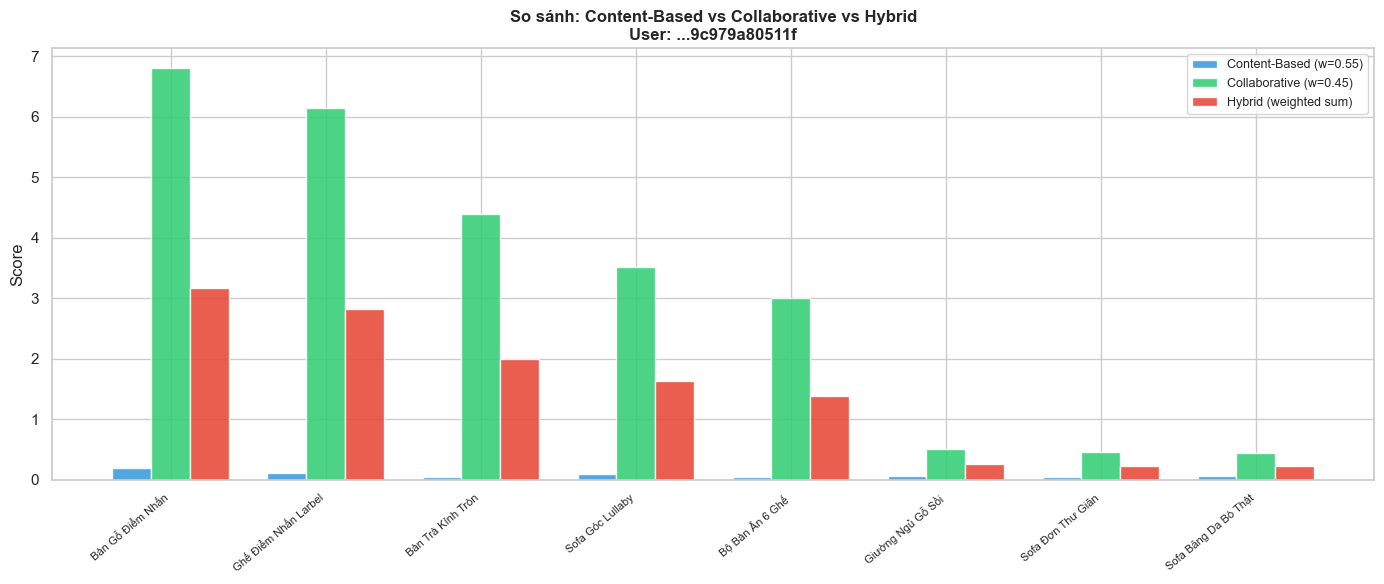

In [7]:
if not hyb_df.empty:
    x     = np.arange(len(hyb_df))
    width = 0.25
    names = hyb_df['name'].str[:20]

    fig, ax = plt.subplots(figsize=(14, 6))
    b1 = ax.bar(x - width, hyb_df['score_content'], width, label=f'Content-Based (w={WEIGHT_CONTENT})',
                color='#3498db', alpha=0.85)
    b2 = ax.bar(x,          hyb_df['score_collab'],  width, label=f'Collaborative (w={WEIGHT_COLLAB})',
                color='#2ecc71', alpha=0.85)
    b3 = ax.bar(x + width,  hyb_df['score_hybrid'],  width, label='Hybrid (weighted sum)',
                color='#e74c3c', alpha=0.9)

    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=40, ha='right', fontsize=8)
    ax.set_ylabel('Score')
    ax.set_title(f'So sánh: Content-Based vs Collaborative vs Hybrid\nUser: ...{sample_user[-12:]}', fontweight='bold')
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

## 5. Phân tích đóng góp của mỗi model

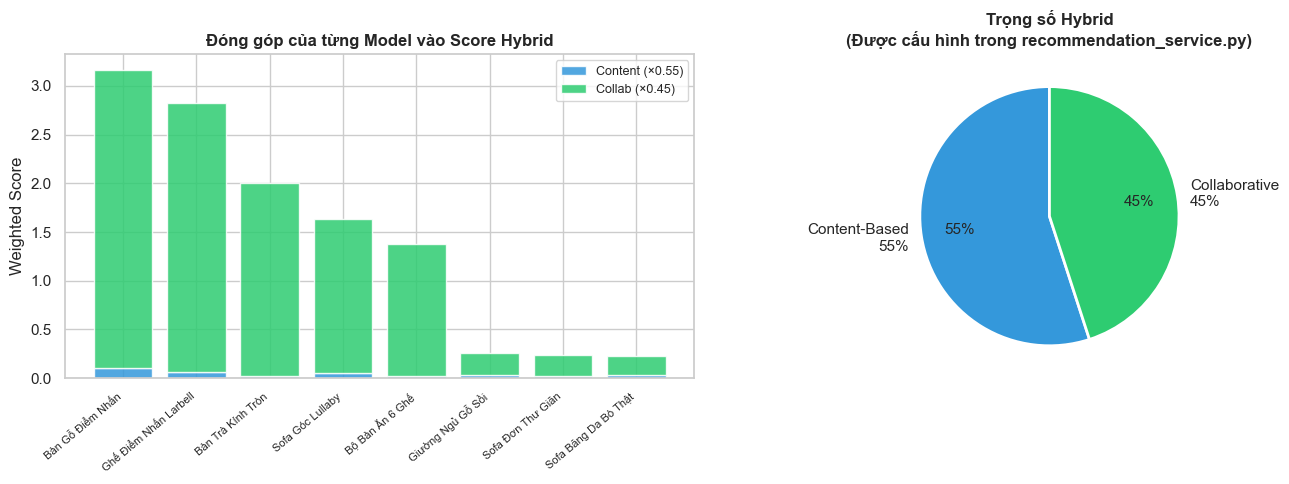

In [8]:
# Stack bar chart thể hiện tỷ lệ đóng góp
if not hyb_df.empty:
    cb_contrib  = hyb_df['score_content'] * WEIGHT_CONTENT
    cf_contrib  = hyb_df['score_collab']  * WEIGHT_COLLAB
    names       = hyb_df['name'].str[:22]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Stack bar
    x = np.arange(len(hyb_df))
    axes[0].bar(x, cb_contrib, label=f'Content (×{WEIGHT_CONTENT})', color='#3498db', alpha=0.85)
    axes[0].bar(x, cf_contrib, bottom=cb_contrib, label=f'Collab (×{WEIGHT_COLLAB})', color='#2ecc71', alpha=0.85)
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(names, rotation=40, ha='right', fontsize=8)
    axes[0].set_title('Đóng góp của từng Model vào Score Hybrid', fontweight='bold')
    axes[0].legend(fontsize=9)
    axes[0].set_ylabel('Weighted Score')

    # Pie chart weights
    axes[1].pie([WEIGHT_CONTENT, WEIGHT_COLLAB],
                labels=[f'Content-Based\n{WEIGHT_CONTENT*100:.0f}%',
                        f'Collaborative\n{WEIGHT_COLLAB*100:.0f}%'],
                colors=['#3498db', '#2ecc71'],
                autopct='%1.0f%%', startangle=90,
                pctdistance=0.7, textprops={'fontsize': 11}, wedgeprops={'linewidth': 2, 'edgecolor': 'white'})
    axes[1].set_title('Trọng số Hybrid\n(Được cấu hình trong recommendation_service.py)', fontweight='bold')

    plt.tight_layout()
    plt.show()

## 7. So sánh kết quả trên tất cả users

In [10]:
# Chạy hybrid cho tất cả users và so sánh
all_results = {}
for uid in matrix.index:
    all_results[uid] = hybrid_recommend(uid, top_k=5)

print('Top-5 Hybrid Recommendations cho mỗi User:')
print('='*65)
for uid, recs in all_results.items():
    print(f'\nUser ID {uid}:')
    for r in recs:
        cb_pct = r['score_content'] * WEIGHT_CONTENT / r['score_hybrid'] * 100 if r['score_hybrid'] else 0
        print(f"   • {r['name'][:30]:<32} hybrid={r['score_hybrid']:.4f}  "
              f"(cb={cb_pct:.0f}% | cf={100-cb_pct:.0f}%)")

Top-5 Hybrid Recommendations cho mỗi User:

User ID 234be2061face0c6afab3a12:
   • Bàn Trà Kính Tròn                hybrid=2.3159  (cb=1% | cf=99%)
   • Bàn Ceilby                       hybrid=2.1406  (cb=4% | cf=96%)
   • Bộ Bàn Ăn 6 Ghế                  hybrid=1.9943  (cb=1% | cf=99%)
   • Sofa Góc Lullaby                 hybrid=1.1021  (cb=4% | cf=96%)
   • Giường Ngủ Gỗ Sồi                hybrid=0.4339  (cb=8% | cf=92%)

User ID 2a7c342dfa799c979a80511f:
   • Bàn Gỗ Điểm Nhấn                 hybrid=3.1676  (cb=3% | cf=97%)
   • Ghế Điểm Nhấn Larbell            hybrid=2.8282  (cb=2% | cf=98%)
   • Bàn Trà Kính Tròn                hybrid=2.0022  (cb=1% | cf=99%)
   • Sofa Góc Lullaby                 hybrid=1.6352  (cb=3% | cf=97%)
   • Bộ Bàn Ăn 6 Ghế                  hybrid=1.3795  (cb=2% | cf=98%)

User ID 50d83bf3615543cb3a606532:
   • Sofa Giường Thông Minh           hybrid=3.1775  (cb=1% | cf=99%)
   • Sofa Góc Lullaby                 hybrid=2.0285  (cb=2% | cf=98%)
   • Bàn Gỗ 

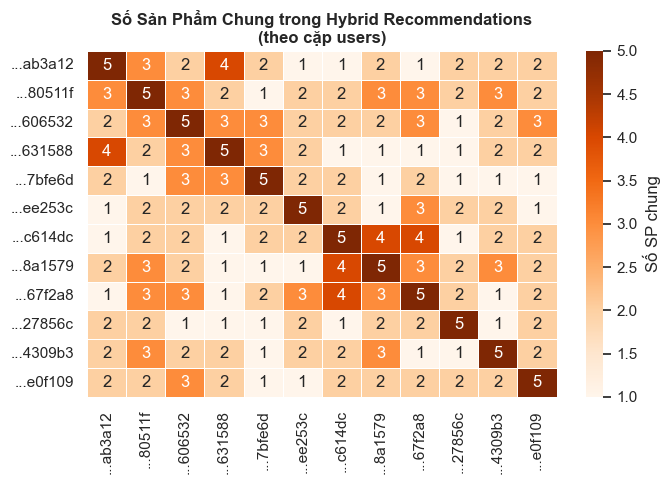

In [11]:
# Phân tích overlap giữa recommendations của các users
user_rec_sets = {uid: set(r['product_id'] for r in recs)
                  for uid, recs in all_results.items()}

uid_list = list(user_rec_sets.keys())
overlap_data = np.zeros((len(uid_list), len(uid_list)))
for i, u1 in enumerate(uid_list):
    for j, u2 in enumerate(uid_list):
        overlap_data[i, j] = len(user_rec_sets[u1] & user_rec_sets[u2])

display_ids = [f'...{u[-6:]}' for u in uid_list]
overlap_df  = pd.DataFrame(overlap_data, index=display_ids, columns=display_ids)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(overlap_df, annot=True, fmt='.0f', cmap='Oranges', ax=ax,
            linewidths=0.5, cbar_kws={'label': 'Số SP chung'})
ax.set_title('Số Sản Phẩm Chung trong Hybrid Recommendations\n(theo cặp users)', fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Tóm tắt luồng xử lý

In [15]:
print(f"""
╔══════════════════════════════════════════════════════════════════╗
║           Hybrid Recommendation – Luồng Xử Lý                    ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  1. content = content_based_recommendation(request)              ║
║     → [product_ids, scores]                                 ║
║                                                                  ║
║  2. collaborative = collaborative_recommendation(request)        ║
║     → [product_ids, scores]                                 ║
║                                                                  ║
║  3. score_map = defaultdict(float)                               ║
║     for item in content:                                         ║
║         score_map[pid] += {WEIGHT_CONTENT} × score_content       ║
║     for item in collaborative:                                   ║
║         score_map[pid] += {WEIGHT_COLLAB} × score_collab         ║
║                                                                  ║
║  4. sorted(score_map)[:top_k]                                    ║
║                                                                  ║
║  5. OUTPUT: {{recommendations, model:'hybrid', weights:{{...}}}} ║
╚══════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════╗
║           Hybrid Recommendation – Luồng Xử Lý                    ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  1. content = content_based_recommendation(request)              ║
║     → [product_ids, scores]                                 ║
║                                                                  ║
║  2. collaborative = collaborative_recommendation(request)        ║
║     → [product_ids, scores]                                 ║
║                                                                  ║
║  3. score_map = defaultdict(float)                               ║
║     for item in content:                                         ║
║         score_map[pid] += 0.55 × score_content       ║
║     for item in collaborative:                                   ║
║         score_map[pid] += 0.45 × score_collab        